In [4]:
# might have to do this outside of the codespace but this makes this so much harder to understand
import qutip as qt
import numpy as np
import matplotlib.pyplot as plt
from quantum_logical.channel import AmplitudeDamping, PhaseDamping
from quantum_logical.trotter import TrotterGroup
from tqdm import tqdm
from quantum_logical.operators import selective_destroy
from scipy.optimize import curve_fit

In [2]:
# generating parameters and creating initial state
T1 = 50
T2 = 25
N = 5
dim = 2
trotter_dt = .02
psi0 = qt.tensor((qt.basis(dim, 1)).unit(), qt.basis(dim, 0), qt.basis(dim, 0), qt.basis(dim, 0), qt.basis(dim, 0))
# psi0 = qt.basis(dim, 1)
rho0 = psi0 * psi0.dag()
amp_damp_channel = AmplitudeDamping(T1, num_qubits=N, hilbert_space_dim=dim)
phase_damp_channel = PhaseDamping(T1, T2, num_qubits=N, hilbert_space_dim=dim)
trotter = TrotterGroup(
    continuous_operators=[amp_damp_channel, phase_damp_channel],
    trotter_dt=trotter_dt,
)

In [3]:
# create the list of gates that will be used
rz1 = qt.rz(target=0, phi= - np.pi / 2)
rz2 = qt.rz(target=0, phi= np.pi / 2)
rx1 = qt.rx(target=0, phi= np.pi / 2)
iswap1 = qt.iswap(N = 5, targets=[0, 4])

iswap2 = qt.iswap(N = 5, targets=[1, 3])

iswap3 = qt.iswap(N = 5, targets=[1, 4])

iswap4 = qt.iswap(N = 5, targets=[2, 4])

z_gate = qt.Qobj([[1, 0], [0, -1]])

hada = 1/np.sqrt(2) * qt.Qobj([[1, 1], [1, -1]])

hada_layer = qt.tensor(hada, hada, hada, qt.qeye(dim), qt.qeye(dim))

cnot1 = qt.cnot(N=5, control=0, target=1)
cnot2 = qt.cnot(N=5, control=0, target=2)

cnot3 = qt.cnot(N=5, control=0, target=3)
cnot4 = qt.cnot(N=5, control=1, target=3)

cnot5 = qt.cnot(N=5, control=1, target=4)
cnot6 = qt.cnot(N=5, control=2, target=4)

set_1 = qt.tensor(rz1, qt.qeye(dim), qt.qeye(dim), rz2 * rx1, qt.qeye(dim))

set_2 = qt.tensor(rx1, qt.qeye(dim), qt.qeye(dim), qt.qeye(dim), qt.qeye(dim))

set_3 = qt.tensor(qt.qeye(dim), rz1, qt.qeye(dim), rz2 * rx1 * rz2, qt.qeye(dim))

set_4 = qt.tensor(qt.qeye(dim), rx1, qt.qeye(dim), qt.qeye(dim), qt.qeye(dim))

set_5 = qt.tensor(qt.qeye(dim), rx1 , qt.qeye(dim), rz2, rz2 * rx1)

set_6 = qt.tensor(qt.qeye(dim), rx1, qt.qeye(dim), qt.qeye(dim), qt.qeye(dim))

set_7 = qt.tensor(qt.qeye(dim), qt.qeye(dim), rz2, qt.qeye(dim), rz2 * rx1 * rz2)

set_8 = qt.tensor(qt.qeye(dim), qt.qeye(dim), rx1, qt.qeye(dim), qt.qeye(dim))

set_9 = qt.tensor(qt.tensor([qt.qeye(dim)] * 4), rz2) 

/var/folders/nc/8sqqbv456mdfx096ks86vy8m0000gn/T/ipykernel_58761/393364893.py:2: DeprecationWarning: Importing functions/classes of the qip submodule directly from the namespace qutip is deprecated. Please import them from the submodule instead, e.g.
from qutip.qip.operations import cnot
from qutip.qip.circuit import QubitCircuit

  rz1 = qt.rz(target=0, phi= - np.pi / 2)
/var/folders/nc/8sqqbv456mdfx096ks86vy8m0000gn/T/ipykernel_58761/393364893.py:3: DeprecationWarning: Importing functions/classes of the qip submodule directly from the namespace qutip is deprecated. Please import them from the submodule instead, e.g.
from qutip.qip.operations import cnot
from qutip.qip.circuit import QubitCircuit

  rz2 = qt.rz(target=0, phi= np.pi / 2)
/var/folders/nc/8sqqbv456mdfx096ks86vy8m0000gn/T/ipykernel_58761/393364893.py:4: DeprecationWarning: Importing functions/classes of the qip submodule directly from the namespace qutip is deprecated. Please import them from the submodule instead, e.g.
f

In [4]:
# creating the initial state and encoding it 
psi0 = qt.tensor(qt.basis(dim, 1), qt.basis(dim, 0), qt.basis(dim, 0), qt.basis(dim, 0), qt.basis(dim, 0))
rho0 = psi0 * psi0.dag()
rho_encoded = cnot2 * cnot1 * rho0 * cnot1.dag() * cnot2.dag()
rho_encoded = hada_layer * rho_encoded * hada_layer.dag()
# trace out the ancillas to get the true result
rho_encoded_traced = qt.ptrace(rho_encoded, [0, 1, 2])
# the correct initial state has been prepared 
rho_encoded_traced 

Quantum object: dims = [[2, 2, 2], [2, 2, 2]], shape = (8, 8), type = oper, isherm = True
Qobj data =
[[ 0.125 -0.125 -0.125  0.125 -0.125  0.125  0.125 -0.125]
 [-0.125  0.125  0.125 -0.125  0.125 -0.125 -0.125  0.125]
 [-0.125  0.125  0.125 -0.125  0.125 -0.125 -0.125  0.125]
 [ 0.125 -0.125 -0.125  0.125 -0.125  0.125  0.125 -0.125]
 [-0.125  0.125  0.125 -0.125  0.125 -0.125 -0.125  0.125]
 [ 0.125 -0.125 -0.125  0.125 -0.125  0.125  0.125 -0.125]
 [ 0.125 -0.125 -0.125  0.125 -0.125  0.125  0.125 -0.125]
 [-0.125  0.125  0.125 -0.125  0.125 -0.125 -0.125  0.125]]

In [5]:
# store the states and the fidelities that come out
states = []
fids = []

In [6]:
# run the circuit 
initial_time = .02
initial_state_relax = trotter.apply(rho_encoded, duration=initial_time, discrete_unitary=qt.qeye(dim ** N))
for i in range(len(initial_state_relax)):
    a = qt.ptrace(initial_state_relax[i], [0, 1, 2])
    states.append(hada_layer * initial_state_relax[i] * hada_layer.dag()) # storing the state in the computational basis 
    fids.append(qt.fidelity(a, rho_encoded_traced))

# apply the hadamards to the state to put them in the computational basis
state_first_hada = hada_layer * initial_state_relax[-1] * hada_layer.dag()

# beginning the stabilizer
# execute the first layer but for this the only gates that will take time is the iswap gate
set1_time = .02 
set1 = trotter.apply(state_first_hada, duration=set1_time, discrete_unitary=set_1)
# this will be in the computational basis (i will say when it switches over to the other one)
for i in set1:
    states.append(i)
    a = hada_layer * i * hada_layer.dag()
    a = qt.ptrace(a, [0, 1, 2])
    fids.append(qt.fidelity(a, rho_encoded_traced))


iswap_1_time = .05
iswap_1 = trotter.apply(set1[-1], duration=iswap_1_time, discrete_unitary=iswap1)
for i in iswap_1:
    states.append(i)
    a = hada_layer * i * hada_layer.dag()
    a = qt.ptrace(a, [0, 1, 2])
    fids.append(qt.fidelity(a, rho_encoded_traced))

set2_time = .02
set2 = trotter.apply(iswap_1[-1], duration=set2_time, discrete_unitary=set_2)
for i in set2:
    states.append(i)
    a = hada_layer * i * hada_layer.dag()
    a = qt.ptrace(a, [0, 1, 2])
    fids.append(qt.fidelity(a, rho_encoded_traced))

iswap_2_time = .05 
iswap_2 = trotter.apply(set2[-1], duration=iswap_2_time, discrete_unitary=iswap1)
for i in iswap_2:
    states.append(i)
    a = hada_layer * i * hada_layer.dag()
    a = qt.ptrace(a, [0, 1, 2])
    fids.append(qt.fidelity(a, rho_encoded_traced))

set3_time = .02
set3 = trotter.apply(iswap_2[-1], duration=set3_time, discrete_unitary=set_3)
for i in set3:
    states.append(i)
    a = hada_layer * i * hada_layer.dag()
    a = qt.ptrace(a, [0, 1, 2])
    fids.append(qt.fidelity(a, rho_encoded_traced))

iswap_3_time = .05
iswap_3 = trotter.apply(set3[-1], duration=iswap_3_time, discrete_unitary=iswap2)
for i in iswap_3:
    states.append(i)
    a = hada_layer * i * hada_layer.dag()
    a = qt.ptrace(a, [0, 1, 2])
    fids.append(qt.fidelity(a, rho_encoded_traced))

set4_time = .02
set4 = trotter.apply(iswap_3[-1], duration=set4_time, discrete_unitary=set_4)
for i in set4:
    states.append(i)
    a = hada_layer * i * hada_layer.dag()
    a = qt.ptrace(a, [0, 1, 2])
    fids.append(qt.fidelity(a, rho_encoded_traced))

iswap_4_time = .05
iswap_4 = trotter.apply(set4[-1], duration=iswap_4_time, discrete_unitary=iswap2)
for i in iswap_4:
    states.append(i)
    a = hada_layer * i * hada_layer.dag()
    a = qt.ptrace(a, [0, 1, 2])
    fids.append(qt.fidelity(a, rho_encoded_traced))

set5_time = .02
set5 = trotter.apply(iswap_4[-1], duration=set5_time, discrete_unitary=set_5)
for i in set5:
    states.append(i)
    a = hada_layer * i * hada_layer.dag()
    a = qt.ptrace(a, [0, 1, 2])
    fids.append(qt.fidelity(a, rho_encoded_traced))

iswap_5_time = .05
iswap_5 = trotter.apply(set5[-1], duration=iswap_5_time, discrete_unitary=iswap3)
for i in iswap_5:
    states.append(i)
    a = hada_layer * i * hada_layer.dag()
    a = qt.ptrace(a, [0, 1, 2])
    fids.append(qt.fidelity(a, rho_encoded_traced))

set6_time = .02
set6 = trotter.apply(iswap_5[-1], duration=set6_time, discrete_unitary=set_6)
for i in set6:
    states.append(i)
    a = hada_layer * i * hada_layer.dag()
    a = qt.ptrace(a, [0, 1, 2])
    fids.append(qt.fidelity(a, rho_encoded_traced))

iswap_6_time = .05
iswap_6 = trotter.apply(set6[-1], duration=iswap_6_time, discrete_unitary=iswap3)
for i in iswap_6:
    states.append(i)
    a = hada_layer * i * hada_layer.dag()
    a = qt.ptrace(a, [0, 1, 2])
    fids.append(qt.fidelity(a, rho_encoded_traced))

set7_time = .02
set7 = trotter.apply(iswap_6[-1], duration=set7_time, discrete_unitary=set_7)
for i in set7:
    states.append(i)
    a = hada_layer * i * hada_layer.dag()
    a = qt.ptrace(a, [0, 1, 2])
    fids.append(qt.fidelity(a, rho_encoded_traced))

iswap_7_time = .05
iswap_7 = trotter.apply(set7[-1], duration=iswap_7_time, discrete_unitary=iswap4)
for i in iswap_7:
    states.append(i)
    a = hada_layer * i * hada_layer.dag()
    a = qt.ptrace(a, [0, 1, 2])
    fids.append(qt.fidelity(a, rho_encoded_traced))

set8_time = .02
set8 = trotter.apply(iswap_7[-1], duration=set8_time, discrete_unitary=set_8)
for i in set8:
    states.append(i)
    a = hada_layer * i * hada_layer.dag()
    a = qt.ptrace(a, [0, 1, 2])
    fids.append(qt.fidelity(a, rho_encoded_traced))

iswap_8_time = .05
iswap_8 = trotter.apply(set8[-1], duration=iswap_8_time, discrete_unitary=iswap4)
for i in iswap_8:
    states.append(i)
    a = hada_layer * i * hada_layer.dag()
    a = qt.ptrace(a, [0, 1, 2])
    fids.append(qt.fidelity(a, rho_encoded_traced))

set9_time = .02
set9 = trotter.apply(iswap_8[-1], duration=set9_time, discrete_unitary=set_9)
for i in set8:
    states.append(i)
    a = hada_layer * i * hada_layer.dag()
    a = qt.ptrace(a, [0, 1, 2])
    fids.append(qt.fidelity(a, rho_encoded_traced))

# this is the end of the cnots 
# not it makes sense to take it back to the +,- basis 
# taking it out of the computational basis 
# set_after_cnots = hada_layer * set9[-1] * hada_layer.dag()



In [7]:
# projective measurement 
projection_operator_00 = qt.tensor(qt.qeye(dim), qt.qeye(dim), qt.qeye(dim), (qt.tensor(qt.basis(dim, 0), qt.basis(dim, 0)) * (qt.tensor(qt.basis(dim, 0), qt.basis(dim, 0))).dag()))
projection_operator_01 = qt.tensor(qt.qeye(dim), qt.qeye(dim), qt.qeye(dim), (qt.tensor(qt.basis(dim, 0), qt.basis(dim, 1)) * (qt.tensor(qt.basis(dim, 0), qt.basis(dim, 1))).dag()))
projection_operator_10 = qt.tensor(qt.qeye(dim), qt.qeye(dim), qt.qeye(dim), (qt.tensor(qt.basis(dim, 1), qt.basis(dim, 0)) * (qt.tensor(qt.basis(dim, 1), qt.basis(dim, 0))).dag())) 
projection_operator_11 = qt.tensor(qt.qeye(dim), qt.qeye(dim), qt.qeye(dim), (qt.tensor(qt.basis(dim, 1), qt.basis(dim, 1)) * (qt.tensor(qt.basis(dim, 1), qt.basis(dim, 1))).dag()))

In [8]:
# apply the recovery gate
# measurement step is instantaneous 
rho00 = projection_operator_00 * set9[-1] * projection_operator_00.dag() / np.trace(projection_operator_00 * set9[-1] * projection_operator_00.dag())
rho01 = projection_operator_01 * set9[-1] * projection_operator_01.dag() / np.trace(projection_operator_01 * set9[-1] * projection_operator_01.dag())
rho10 = projection_operator_10 * set9[-1] * projection_operator_10.dag() / np.trace(projection_operator_10 * set9[-1] * projection_operator_10.dag())
rho11 = projection_operator_11 * set9[-1] * projection_operator_11.dag() / np.trace(projection_operator_11 * set9[-1] * projection_operator_11.dag())

# now you have to trotterize all of these separately and then bring them back together this is a way to get around this but roger thinks its dumb 
# correction_operators
r00 = qt.tensor(qt.qeye(dim ** N))
r01 = qt.Qobj((qt.tensor(qt.qeye(dim), z_gate, qt.qeye(dim ** 3))).full())
r10 = qt.Qobj((qt.tensor(z_gate, qt.qeye(dim ** 4))).full())
r11 = qt.Qobj((qt.tensor(qt.qeye(dim), qt.qeye(dim), z_gate, qt.qeye(dim ** 2))).full())

In [9]:
recovery_time = .04

# putting the states in the hadamard basis 
rho00 = hada_layer * rho00 * hada_layer.dag()
rho01 = hada_layer * rho01 * hada_layer.dag()
rho10 = hada_layer * rho10 * hada_layer.dag()
rho11 = hada_layer * rho11 * hada_layer.dag()
# measurement = trotter.apply(final_state, duration=measurement_dur, discrete_unitary=qt.qeye(dim ** N))
recovery1 = trotter.apply(rho00, duration=recovery_time, discrete_unitary=r00)
# states.extend(recovery1)
# fids.append(qt.fidelity(qt.ptrace(recovery1[-1], [0, 1, 2]), rho_encoded_traced))
recovery2 = trotter.apply(rho01, duration=recovery_time, discrete_unitary=r01)
recovery3 = trotter.apply(rho10, duration=recovery_time, discrete_unitary=r10)
recovery4 = trotter.apply(rho11, duration=recovery_time, discrete_unitary=r11)

# have to add them back to get the overall density matrix 
for i in range(len(recovery1)):
    total_state = (np.trace(projection_operator_00 * set9[-1] * projection_operator_00.dag()) * recovery1[i] + 
                   np.trace(projection_operator_01 * set9[-1] * projection_operator_01.dag()) * recovery2[i] + 
                   np.trace(projection_operator_10 * set9[-1] * projection_operator_10.dag()) * recovery3[i] + 
                   np.trace(projection_operator_11 * set9[-1] * projection_operator_11.dag()) * recovery4[i])
    total_state_normal = total_state / np.trace(total_state)
    total_state_trace = qt.ptrace(total_state_normal, [0, 1, 2])
    fids.append(qt.fidelity(total_state_trace, rho_encoded_traced))
    total_state_normal = hada_layer * total_state_normal * hada_layer.dag() # doing this in order to put the state in the computational basis 
    states.append(total_state_normal)

total_time = (recovery_time + set1_time + set2_time + set3_time + set4_time + set5_time + initial_time +
              set6_time + set7_time + set8_time + set9_time + iswap_1_time + iswap_2_time + iswap_3_time +
              iswap_4_time + iswap_5_time + iswap_6_time + iswap_7_time + iswap_8_time)

In [10]:
# trace out the ancillas
state_new = []
for i in range(len(states)):
    state_new.append(qt.ptrace(states[i], [0, 1, 2]))

time = np.linspace(0, total_time, len(states))

/Users/girgis/Documents/GitHub/quantum_logical/venv/lib/python3.9/site-packages/matplotlib/cbook.py:1699: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/girgis/Documents/GitHub/quantum_logical/venv/lib/python3.9/site-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


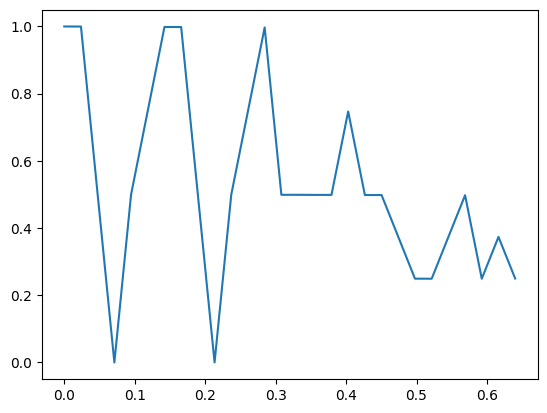

In [11]:
fig, ax = plt.subplots()
data = []
for i in range(len(state_new)):
    data.append(state_new[i][7, 7])
ax.plot(time, data, label = "|+++>")

In [66]:
# making a list 
# this makes the matricies for the isometry this is not hard 
# now the gates can be made from it and this is not hard 
N = 2
dim = 3
nums_block = []
for i in range(N): # 3 here is the new dim size
    # two here is the old dim size
    nums_block.append(i * 3 + 2)

matrix_make = np.zeros((2 ** 2, 3 ** 2))
# for i in [0,1,2,3]:
#     for j in range(2 ** 2 + 2):
#         if j != nums_block:
#             matrix_make[i,j] = 1
list1 = []
# the two here is the first part of the matrix above row
for i in range(4):
    list1.append(i)

list2 = [] 
# the two here is the old dim and the three here is the new dim of the matrix 
for j in range(4 + 8):
    if j not in nums_block:
        list2.append(j)

for i in range(len(list1)):
    matrix_make[list1[i], list2[i]] = 1

In [67]:
nums_block

[2, 5]

In [68]:
qt.Qobj(matrix_make)

Quantum object: dims = [[4], [9]], shape = (4, 9), type = oper, isherm = False
Qobj data =
[[1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0.]]

In [69]:
nums_block

[2, 5]